# Demo 13 - Heston calibration versus eSSVI surface and direct local-vol PDE audit

This notebook is the final Capstone 3 comparison artifact. It keeps the demo layer thin: build the deterministic market-like synthetic fixture, calibrate Heston once with robust quadrature under the library's `vega_scaled_price` objective, rerun headline diagnostics at diagnostics quality, call `run_heston_vs_local_vol_comparison(...)`, and display the packaged tables and plots without rebuilding pricing, eSSVI, Dupire, PDE, residual, bucket, or tradeoff logic in the notebook.

In [1]:
from __future__ import annotations

import sys
from pathlib import Path

for candidate in (Path.cwd(), *Path.cwd().parents):
    src = candidate / "src"
    if (src / "option_pricing").exists():
        sys.path.insert(0, str(src))
        break

## Imports

In [2]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import Markdown, display

from option_pricing.diagnostics.heston import (
    build_market_like_heston_quote_set,
    plot_heston_model_comparison_error_buckets,
    plot_heston_model_comparison_iv_residual_heatmap,
    plot_heston_model_comparison_smile_overlay,
    plot_heston_model_comparison_train_heldout,
    run_heston_calibration_fit_diagnostics,
    run_heston_vs_local_vol_comparison,
)
from option_pricing.models.heston.calibration import calibrate_heston_multistart
from option_pricing.models.heston.calibration.bounds import HestonCalibrationBounds
from option_pricing.models.heston.params import HESTON_PARAM_NAMES
from option_pricing.numerics.quadrature import QuadratureConfig
from option_pricing.vol.ssvi import ESSVICalibrationConfig, ESSVIProjectionConfig

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 140)
pd.set_option("display.max_colwidth", 88)

## Common target quote set

The target is a deterministic market-like synthetic fixture. It is not market data and is not generated from the fitted Heston model. The held-out split is defined once and passed into diagnostics so each comparison row carries the same `train` or `held_out` label.

In [3]:
robust_quad_cfg = QuadratureConfig(u_max=220.0, n_panels=44, nodes_per_panel=24)
diagnostics_quad_cfg = QuadratureConfig(u_max=260.0, n_panels=56, nodes_per_panel=32)

quotes = build_market_like_heston_quote_set(
    expiries=np.array([0.5, 1.0, 2.0], dtype=np.float64),
    log_moneyness=np.array([-0.12, -0.06, 0.0, 0.06, 0.12], dtype=np.float64),
)

held_out_mask = np.zeros(quotes.n_quotes, dtype=np.bool_)
held_out_mask[4::5] = True

pd.DataFrame(
    {
        "quote_index": np.arange(quotes.n_quotes, dtype=np.int64),
        "expiry": quotes.expiry,
        "log_moneyness": quotes.log_moneyness,
        "strike": quotes.strike,
        "market_iv": quotes.iv_mid,
        "market_price": quotes.mid,
        "sample": np.where(held_out_mask, "held_out", "train"),
    }
)

,quote_index,expiry,log_moneyness,strike,market_iv,market_price,sample
0,0,0.5,-0.12,89.136614,0.199999,12.710560,train
1,1,0.5,-0.06,94.648515,0.190198,8.582610,train
2,2,0.5,0.00,100.501252,0.182750,5.125999,train
3,3,0.5,0.06,106.715902,0.177654,2.635050,train
4,4,0.5,0.12,113.314845,0.174911,1.150438,held_out
5,5,1.0,-0.12,89.583414,0.205816,14.513056,train
6,6,1.0,-0.06,95.122942,0.197284,10.781231,train
7,7,1.0,0.00,101.005017,0.191030,7.533723,train
8,8,1.0,0.06,107.250818,0.187055,4.931092,train
9,9,1.0,0.12,113.882838,0.185357,3.033497,held_out


## Heston calibration

The notebook uses the library multistart calibrator and then hands the result to the comparison diagnostic. Calibration optimizes `vega_scaled_price` as a robust proxy for IV error; IV RMSE stays a reported diagnostic rather than a direct optimizer target. The optimizer settings are intentionally small and deterministic for demo runtime.

In [4]:
bounds = HestonCalibrationBounds()
heston_fit = calibrate_heston_multistart(
    quotes=quotes,
    objective_type="vega_scaled_price",
    bounds=bounds,
    quad_cfg=robust_quad_cfg,
    max_seeds=6,
    parameter_transform="bounded",
    loss="linear",
    max_nfev=100,
)

headline_diagnostics = run_heston_calibration_fit_diagnostics(
    quotes=quotes,
    fit=heston_fit,
    held_out_mask=held_out_mask,
    quad_cfg=diagnostics_quad_cfg,
    objective_slice_grid_size=2,
)

pd.DataFrame(
    {
        "parameter": HESTON_PARAM_NAMES,
        "seed": heston_fit.best_run.seed_params.as_array(),
        "fitted": heston_fit.best_params.as_array(),
        "lower_bound": bounds.lower_array(),
        "upper_bound": bounds.upper_array(),
    }
)

,parameter,seed,fitted,lower_bound,upper_bound
0,kappa,1.500000,1.208712,0.050000,20.000
1,vbar,0.029512,0.056404,0.000001,1.000
2,eta,0.670488,0.359587,0.000100,5.000
3,rho,-0.106154,-0.315017,-0.999000,0.999
4,v,0.033398,0.030133,0.000001,1.000


In [5]:
pd.DataFrame(
    [
        {
            "seed_index": heston_fit.best_run.seed_index,
            "success": heston_fit.best_run.success,
            "cost": heston_fit.best_run.cost,
            "optimality": heston_fit.best_run.optimality,
            "nfev": heston_fit.best_run.nfev,
            "message": heston_fit.best_run.message,
        }
    ]
)

,seed_index,success,cost,optimality,nfev,message
0,4,True,0.000007,1.875190e-09,19,`gtol` termination condition is satisfied.


## Heston versus eSSVI surface and direct local-vol PDE audit

The comparison object is the source of truth for residual rows, summary metrics, held-out splits, buckets, tradeoffs, and limitation notes. It separates Heston versus eSSVI implied-surface repricing from the smaller direct local-vol PDE audit grid.

In [6]:
comparison = run_heston_vs_local_vol_comparison(
    quotes=quotes,
    heston_fit=heston_fit,
    held_out_mask=held_out_mask,
    heston_quad_cfg=robust_quad_cfg,
    essvi_cfg=ESSVICalibrationConfig(max_nfev=800),
    essvi_projection_cfg=ESSVIProjectionConfig(
        validation_nt=21,
        validation_y_min=-0.60,
        validation_y_max=0.60,
        validation_ny=41,
        dupire_nt=15,
        dupire_y_min=-0.50,
        dupire_y_max=0.50,
        dupire_ny=31,
        strict_validation=False,
    ),
    local_vol_pde_max_quotes=9,
    local_vol_pde_Nx=81,
    local_vol_pde_Nt=121,
)

assert set(comparison.tables) >= {
    "fit_errors",
    "error_summary",
    "held_out_comparison",
    "tradeoff_summary",
    "direct_local_vol_pde",
    "direct_local_vol_pde_matched_error_summary",
}
assert comparison.meta["direct_local_vol_pde_repricing"] is True
assert comparison.meta["direct_local_vol_pde_success_count"] > 0

comparison.meta

{'diagnostic': 'heston_vs_local_vol_comparison',
 'models': ['Heston', 'ESSVI local-vol proxy', 'Direct local-vol PDE'],
 'quote_count': 15,
 'train_quote_count': 12,
 'held_out_quote_count': 3,
 'expiry_count': 3,
 'log_moneyness_count': 5,
 'held_out_mask_provided': True,
 'sample_labels': ['train', 'held_out'],
 'comparison_target': 'same HestonQuoteSet quotes repriced by both models',
 'comparison_fixture_label': 'deterministic market-like synthetic fixture',
 'local_vol_proxy_kind': 'essvi_nodal_implied_surface',
 'local_vol_proxy': 'ESSVINodalSurface repricing from calibrate_essvi',
 'local_vol_fit_source': 'computed',
 'heston_backend_config': {'backend': 'gauss_legendre',
  'config_resolution': 'explicit_quad_cfg',
  'u_max': 220.0,
  'n_panels': 44,
  'nodes_per_panel': 24,
  'panel_spacing': 'uniform',
  'cluster_strength': 2.0},
 'essvi_success': True,
 'essvi_nfev': 14,
 'essvi_cost': 5.686911435578668e-05,
 'notes': ['NOTE: The eSSVI row reprices the calibrated implied sur

## Diagnostic plots

These figures consume the packaged comparison diagnostics. The notebook does not rebuild residuals, buckets, train/held-out summaries, Heston pricing, eSSVI repricing, or direct PDE repricing data.

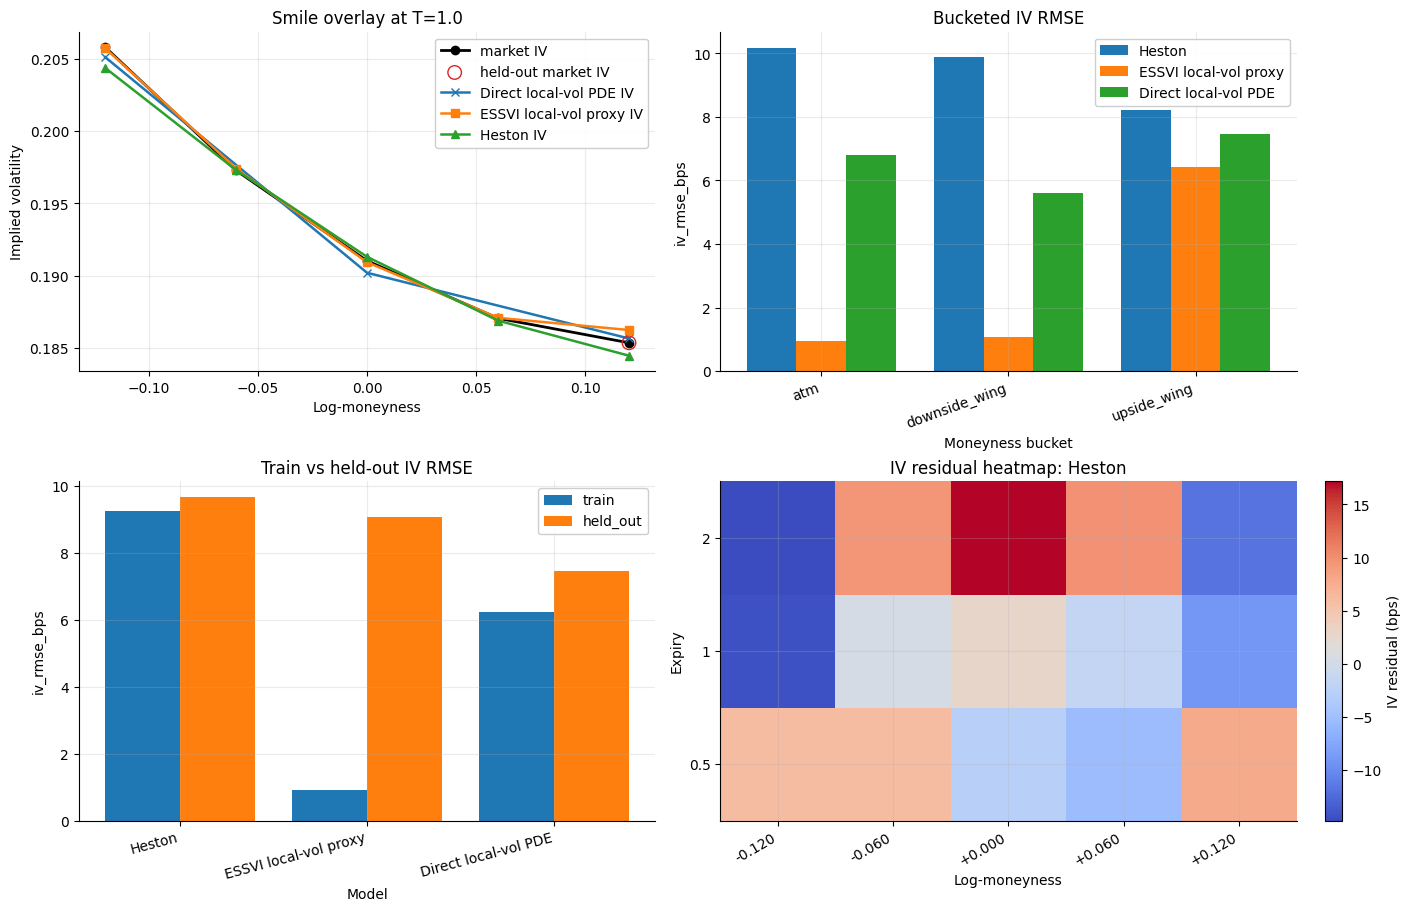

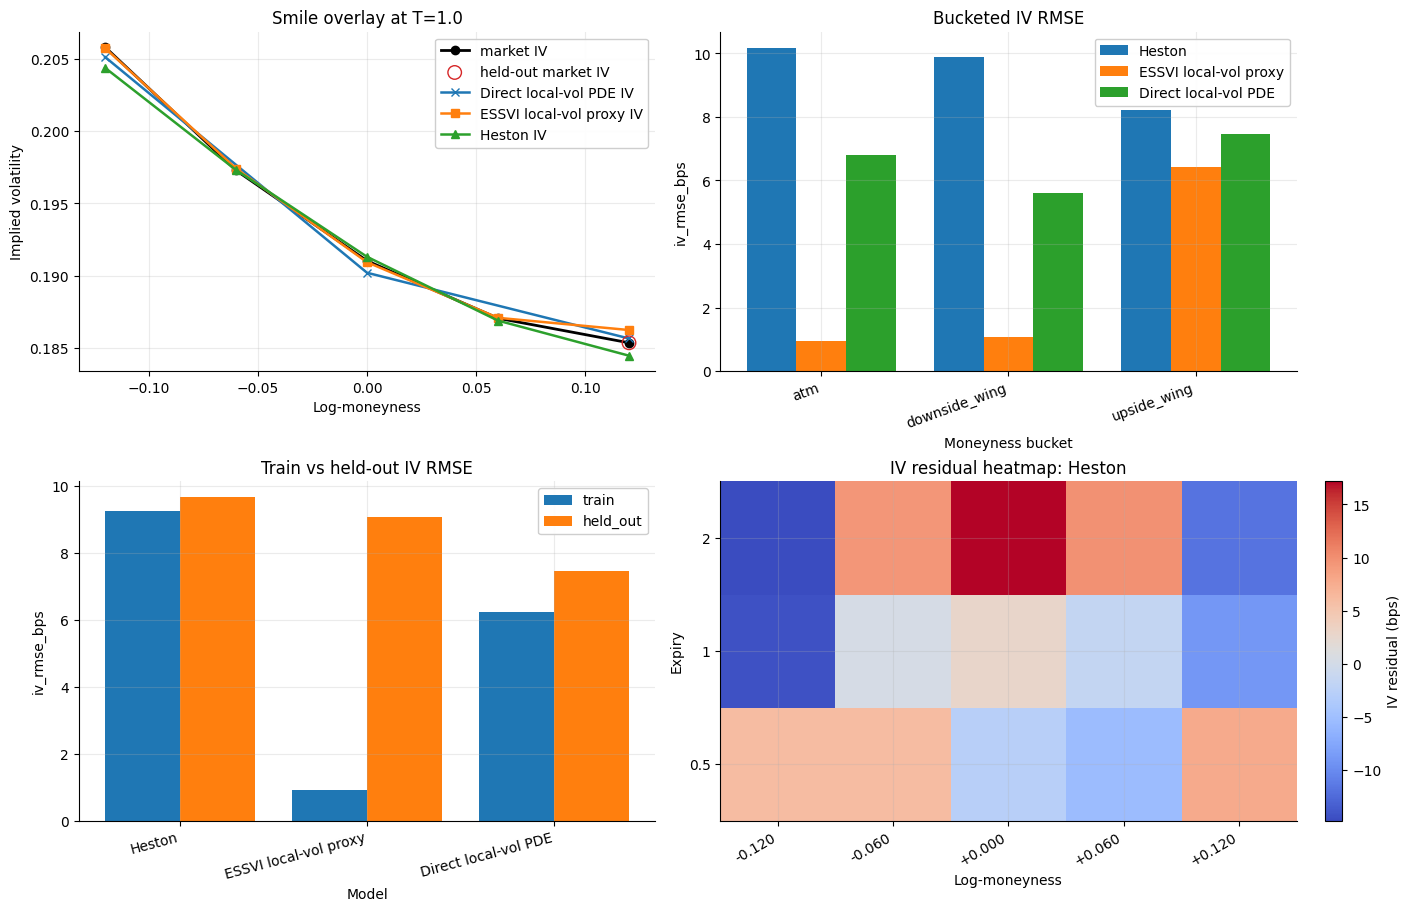

In [7]:
fig, axes = plt.subplots(2, 2, figsize=(14.0, 9.0), constrained_layout=True)

plot_heston_model_comparison_smile_overlay(
    comparison,
    expiry=1.0,
    ax=axes[0, 0],
    title="Smile overlay at T=1.0",
)
plot_heston_model_comparison_error_buckets(
    comparison,
    metric="iv_rmse_bps",
    ax=axes[0, 1],
    title="Bucketed IV RMSE",
)
plot_heston_model_comparison_train_heldout(
    comparison,
    metric="iv_rmse_bps",
    ax=axes[1, 0],
    title="Train vs held-out IV RMSE",
)
plot_heston_model_comparison_iv_residual_heatmap(
    comparison,
    model="Heston",
    ax=axes[1, 1],
    title="IV residual heatmap",
)

fig


## Side-by-side residual heatmaps

The long-form `fit_errors` table is heatmap-ready for each model. This side-by-side view makes maturity and moneyness structure visible without any notebook-local residual logic.

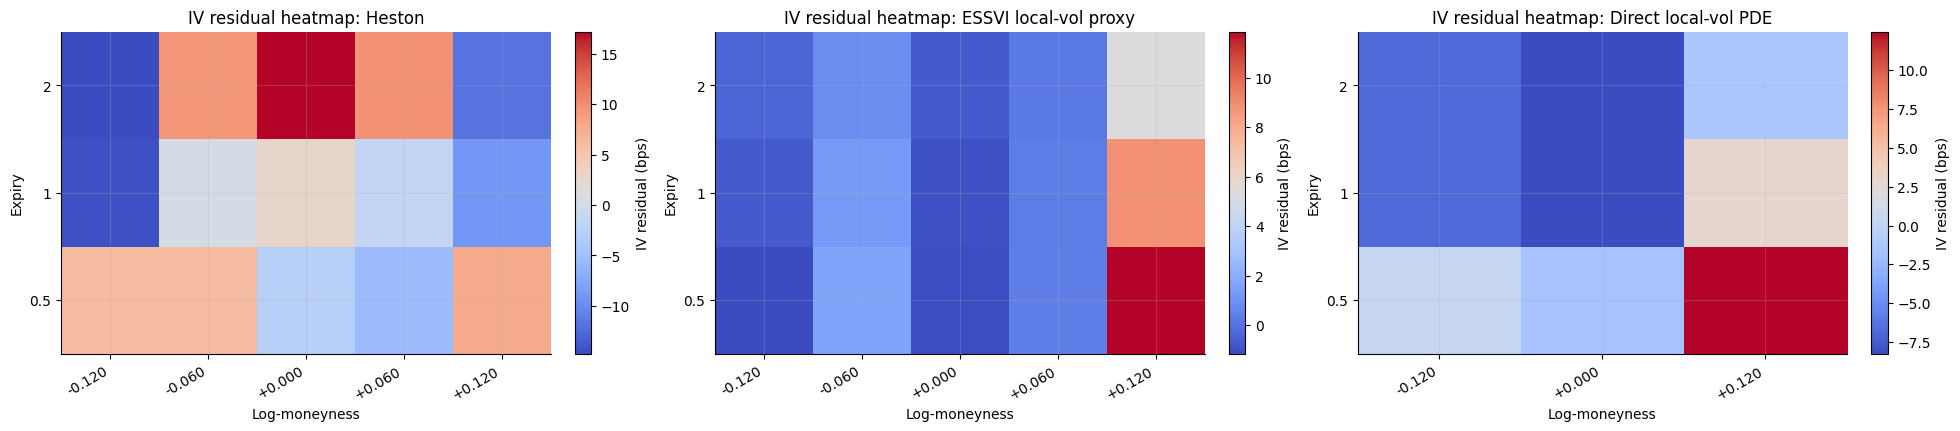

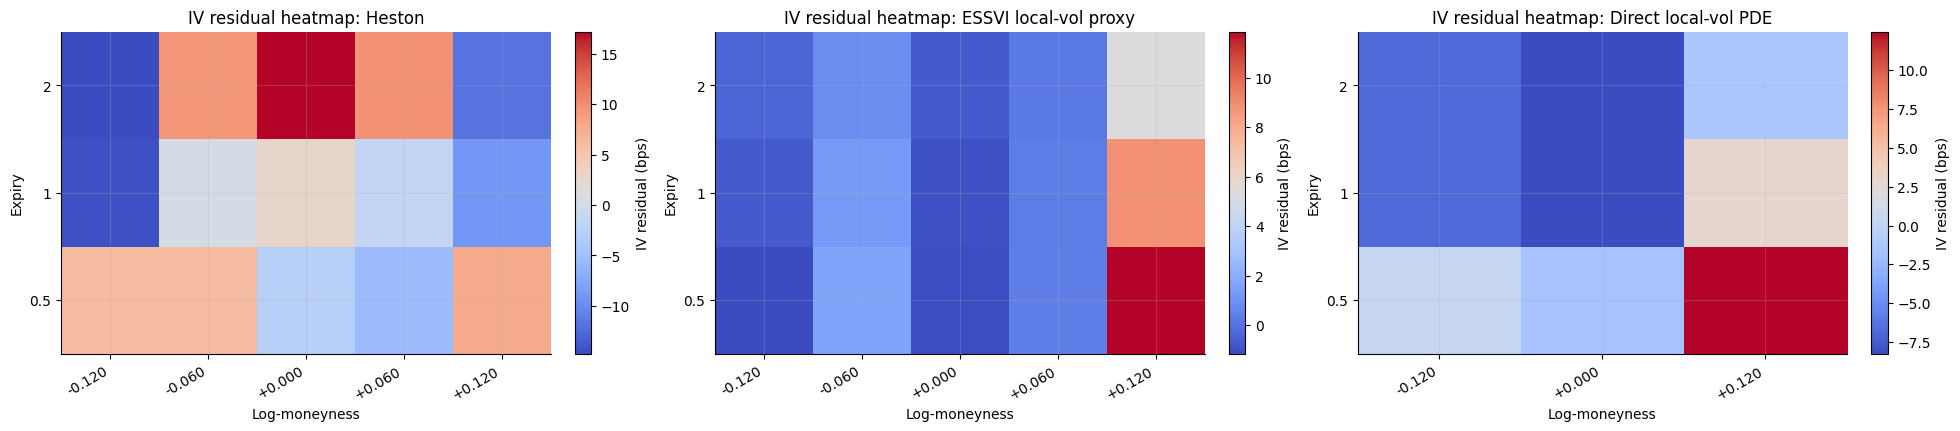

In [8]:
model_names = list(comparison.meta["models"])
fig, axes = plt.subplots(
    1,
    len(model_names),
    figsize=(6.5 * len(model_names), 4.2),
    constrained_layout=True,
)

for ax, model_name in zip(np.atleast_1d(axes), model_names, strict=True):
    plot_heston_model_comparison_iv_residual_heatmap(
        comparison,
        model=model_name,
        ax=ax,
        title="IV residual heatmap",
    )

fig


## Fit quality and held-out split

In [9]:
comparison.tables["held_out_comparison"]

,model,sample,n_quotes,price_rmse,price_mae,price_max_abs,iv_rmse_bps,iv_mae_bps,iv_max_abs_bps
0,Heston,train,12,0.042653,0.031414,0.094102,9.226749,7.511969,17.191006
1,Heston,held_out,3,0.041001,0.035754,0.062646,9.647086,9.495690,11.809177
2,ESSVI local-vol proxy,train,12,0.003079,0.002789,0.004660,0.914962,0.810093,1.658759
3,ESSVI local-vol proxy,held_out,3,0.026958,0.026747,0.029950,9.070513,8.667260,11.855490
4,Direct local-vol PDE,train,6,0.027807,0.022809,0.045191,6.235545,5.371209,8.276761
5,Direct local-vol PDE,held_out,3,0.015252,0.013578,0.023270,7.453914,5.618523,12.482961


In [10]:
comparison.tables["error_summary"]

,model,bucket,n_quotes,price_rmse,price_mae,price_max_abs,iv_rmse_bps,iv_mae_bps,iv_max_abs_bps
0,Heston,all,15,0.042328,0.032282,0.094102,9.312335,7.908713,17.191006
1,Heston,atm,3,0.054866,0.037524,0.094102,10.174456,7.557758,17.191006
2,Heston,downside_wing,6,0.040168,0.031786,0.070261,9.875861,8.466458,14.778968
3,Heston,upside_wing,6,0.036886,0.030157,0.062646,8.216236,7.526445,11.809177
4,ESSVI local-vol proxy,all,15,0.012366,0.007581,0.029950,4.138184,2.381527,11.855490
5,ESSVI local-vol proxy,atm,3,0.003615,0.003597,0.003875,0.942753,0.928208,1.104871
6,ESSVI local-vol proxy,downside_wing,6,0.003431,0.003212,0.004660,1.086514,1.002838,1.658759
7,ESSVI local-vol proxy,upside_wing,6,0.019079,0.013941,0.029950,6.417671,4.486875,11.855490
8,Direct local-vol PDE,all,9,0.024352,0.019732,0.045191,6.666455,5.453647,12.482961
9,Direct local-vol PDE,atm,3,0.032250,0.027362,0.045191,6.808338,6.028492,8.276761


## Matched direct-PDE subset

The full error summary keeps full-set Heston/eSSVI rows and selected direct-PDE rows together for continuity. The matched table below is the packaged diagnostic to use when comparing all three models on the successful direct local-vol PDE quote subset.


In [ ]:
comparison.tables["direct_local_vol_pde_matched_error_summary"]


## Heatmap-ready residual rows

The diagnostic returns quote-level residual rows in long form, including model name, expiry, log-moneyness, bucket, and sample label. A plotting notebook can pivot this table without recomputing either model.

In [11]:
comparison.tables["fit_errors"].loc[
    :,
    [
        "model",
        "quote_index",
        "expiry",
        "log_moneyness",
        "moneyness_bucket",
        "sample",
        "market_iv",
        "model_iv",
        "iv_residual_bps",
        "price_residual",
    ],
]

,model,quote_index,expiry,log_moneyness,moneyness_bucket,sample,market_iv,model_iv,iv_residual_bps,price_residual
0,Heston,0,0.5,-0.12,downside_wing,train,0.199999,0.200600,6.009770,0.011068
1,Heston,1,0.5,-0.06,downside_wing,train,0.190198,0.190797,5.986604,0.014734
2,Heston,2,0.5,0.00,atm,train,0.182750,0.182477,-2.727737,-0.007640
3,Heston,3,0.5,0.06,upside_wing,train,0.177654,0.177124,-5.297015,-0.013638
4,Heston,4,0.5,0.12,upside_wing,held_out,0.174911,0.175687,7.761853,0.014451
5,Heston,5,1.0,-0.12,downside_wing,train,0.205816,0.204381,-14.348741,-0.044741
6,Heston,6,1.0,-0.06,downside_wing,train,0.197284,0.197309,0.247392,0.000901
7,Heston,7,1.0,0.00,atm,train,0.191030,0.191306,2.754531,0.010830
8,Heston,8,1.0,0.06,upside_wing,train,0.187055,0.186893,-1.619651,-0.006234
9,Heston,9,1.0,0.12,upside_wing,held_out,0.185357,0.184466,-8.916041,-0.030164


## Tradeoff summary

The table below is qualitative by design. It supports the final narrative: Heston gives interpretable stochastic-volatility dynamics, eSSVI is the flexible vanilla-surface side, and direct local-vol PDE repricing audits a small Dupire validation grid.

In [12]:
comparison.tables["tradeoff_summary"]

,model,fit_quality_note,interpretability_note,smoothness_extrapolation_note,dynamic_plausibility_note
0,Heston,Five-parameter stochastic-volatility fit can be too rigid for some vanilla smiles.,"Parameters map to mean reversion, long-run variance, vol-of-vol, correlation, and in...",Parametric surface is smooth but extrapolation is model-driven.,Variance dynamics are explicit and can support path-dependent or forward-looking ana...
1,ESSVI local-vol proxy,eSSVI/local-vol-facing proxy can fit vanilla implied-vol targets flexibly at the cal...,Surface parameters describe smile geometry rather than a stochastic variance process.,"Nodal eSSVI gives a smooth implied surface, but local-vol extrapolation and Dupire s...","Local volatility matches vanilla marginals under its surface assumptions, but it doe..."
2,Direct local-vol PDE,Direct PDE repricing audits a small validation grid against the same target quotes r...,Dupire local vol is implied by the calibrated vanilla surface; it is a surface model...,"Numerics depend on the eSSVI projection, local-vol regularity, boundaries, and grid ...",Local volatility matches vanilla marginals under its surface assumptions but does no...


## Notes and limitations

These notes intentionally travel with the diagnostic metadata and should be carried into the capstone narrative.

In [13]:
display(Markdown("\n".join(f"- {note}" for note in comparison.meta["notes"])))

- NOTE: The eSSVI row reprices the calibrated implied surface directly and is retained as a supporting proxy; the direct local-vol PDE table is the Dupire/PDE repricing audit for the selected validation grid.
- NOTE: Moneyness buckets use abs(log_moneyness) <= 0.03 for ATM, log_moneyness < -0.03 for downside wing/skew, and > 0.03 for upside wing.
- LIMITATION: Comparison conclusions depend on the target quotes, fit partition, eSSVI projection, local-vol PDE grid, and boundary policy.